In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df=pd.read_excel("CustomerSegmentation.xlsx")

In [3]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541910, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [11]:
df=df.dropna(subset=["Customer ID"])

In [12]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [13]:
df_original=pd.read_excel("CustomerSegmentation.xlsx")
df_original[df_original["Description"].isnull()][['Customer ID','Description']].head(10)

,Customer ID,Description
622,NaN,NaN
1510,NaN,NaN
1985,NaN,NaN
1986,NaN,NaN
2022,NaN,NaN
2023,NaN,NaN
2024,NaN,NaN
2025,NaN,NaN
2026,NaN,NaN
2406,NaN,NaN


In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
(df['Quantity'] <=0).sum()

np.int64(8872)

In [17]:
(df['Price']<=0).sum()

np.int64(40)

In [18]:
df=df[(df['Quantity']>0) & (df['Price']>0)]

In [19]:
(df['Quantity']<=0).sum()

np.int64(0)

In [20]:
(df['Price']<=0).sum()

np.int64(0)

In [21]:
df['Customer ID']=df['Customer ID'].astype(int)

In [22]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object

In [23]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,392693.000000,392693,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272,3.125952,15287.837224
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492603,NaN,22.241820,1713.542421


## Data Cleaning

The dateset was cleaned by handling missing values, removing duplicate records, checking for invalid values and verifying datatypes to ensure accurate analysis.

In [24]:
df['Sales'] = df['Quantity'] * df['Price']

- A new feature, Sales,was created by multiplying Quantity and Price.This represents the total amount spent for each transaction and is used in customer analysis.

In [25]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
purchase_value=df['Sales'].mean()
print("Average Purchase Value is:",purchase_value)

Average Purchase Value is: 22.631487940961517


In [27]:
purchase_frequency=df.groupby('Customer ID')['Invoice'].nunique()
purchase_frequency.head()

Customer ID
12346    1
12347    7
12348    4
12349    1
12350    1
Name: Invoice, dtype: int64

In [28]:
customer_lifetime_value=df.groupby('Customer ID')['Sales'].sum()
customer_lifetime_value.head()

Customer ID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
Name: Sales, dtype: float64

In [29]:
reference_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [30]:
rfm=df.groupby('Customer ID').agg({'InvoiceDate':'max','Invoice':'nunique','Sales':'sum'})
rfm

,InvoiceDate,Invoice,Sales
Customer ID,,,
12346,2011-01-18 10:01:00,1,77183.60
12347,2011-12-07 15:52:00,7,4310.00
12348,2011-09-25 13:13:00,4,1797.24
12349,2011-11-21 09:51:00,1,1757.55
12350,2011-02-02 16:01:00,1,334.40
...,...,...,...
18280,2011-03-07 09:52:00,1,180.60
18281,2011-06-12 10:53:00,1,80.82
18282,2011-12-02 11:43:00,2,178.05


In [31]:
rfm['Recency']=(reference_date-rfm['InvoiceDate']).dt.days
rfm

,InvoiceDate,Invoice,Sales,Recency
Customer ID,,,,
12346,2011-01-18 10:01:00,1,77183.60,326
12347,2011-12-07 15:52:00,7,4310.00,2
12348,2011-09-25 13:13:00,4,1797.24,75
12349,2011-11-21 09:51:00,1,1757.55,19
12350,2011-02-02 16:01:00,1,334.40,310
...,...,...,...,...
18280,2011-03-07 09:52:00,1,180.60,278
18281,2011-06-12 10:53:00,1,80.82,181
18282,2011-12-02 11:43:00,2,178.05,8


In [32]:
rfm.rename(columns={
    'Invoice':'Frequency',
    'Sales':'Monetary',
}, inplace=True)
rfm

,InvoiceDate,Frequency,Monetary,Recency
Customer ID,,,,
12346,2011-01-18 10:01:00,1,77183.60,326
12347,2011-12-07 15:52:00,7,4310.00,2
12348,2011-09-25 13:13:00,4,1797.24,75
12349,2011-11-21 09:51:00,1,1757.55,19
12350,2011-02-02 16:01:00,1,334.40,310
...,...,...,...,...
18280,2011-03-07 09:52:00,1,180.60,278
18281,2011-06-12 10:53:00,1,80.82,181
18282,2011-12-02 11:43:00,2,178.05,8


In [33]:
rfm=rfm[['Recency','Frequency','Monetary']]
rfm


,Recency,Frequency,Monetary
Customer ID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


## RFM Analysis
RFM analysis summarizes customer behaviour based on how recently customers purchased, how frequently they purchased, how much they spent.

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler=StandardScaler()

In [36]:
rfm_scale = scaler.fit_transform(rfm)
rfm_scale

array([[ 2.33457414e+00, -4.25096503e-01,  8.36301041e+00],
       [-9.05340320e-01,  3.54416797e-01,  2.51698458e-01],
       [-1.75359593e-01, -3.53398530e-02, -2.79882904e-02],
       ...,
       [-8.45341904e-01, -2.95177619e-01, -2.08214809e-01],
       [-8.85340848e-01,  1.52368675e+00, -3.51977046e-04],
       [-4.95351144e-01, -1.65258736e-01, -2.35315745e-02]],
      shape=(4338, 3))

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [38]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(rfm_scale)
    wcss.append(kmeans.inertia_)

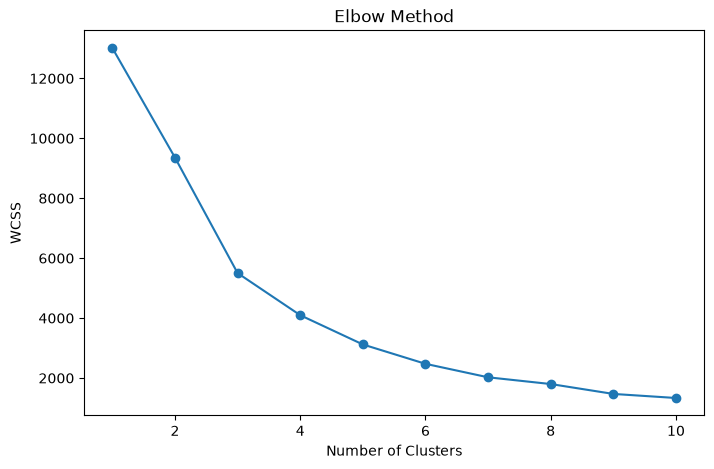

In [39]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Elbow Method
- The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.
- The Within Cluster Sum of Squares(WCSS) decreases as the number of clusters increases.
- A clear elbow is observed at the 4, where the decrease in WCSS starts to become gradual.


In [40]:
kmeans=KMeans(n_clusters=4,random_state=42)
rfm['Cluster']=kmeans.fit_predict(rfm_scale)

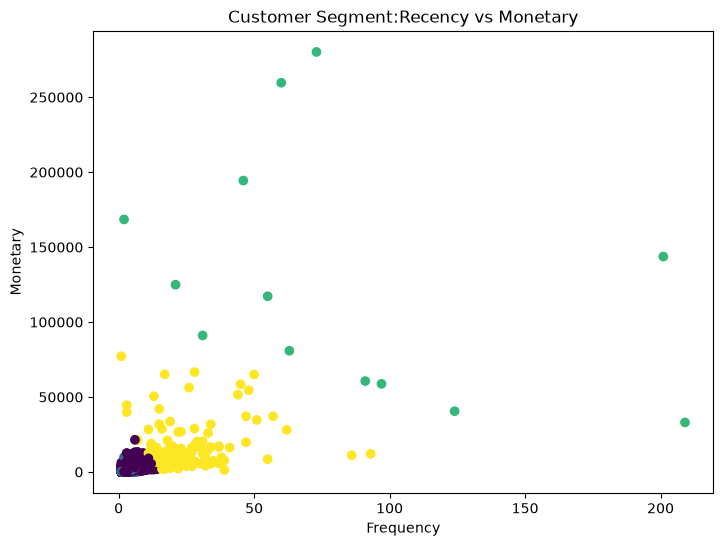

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(rfm['Frequency'],rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segment:Recency vs Monetary')
plt.show()

## Customer Segment : Frequancy vs Monetary
- Customers who purchase more frequently generally have higher total spendings.
- VIP and Loyal customers are grouped in the region with high frequency and high monetary values.
- Inactive customers are concentrated in the lower region, indicating fewer purchase and lower spending.
- The scatter plot shows that K-Means successfully separated customers based on their purchasing behavior.

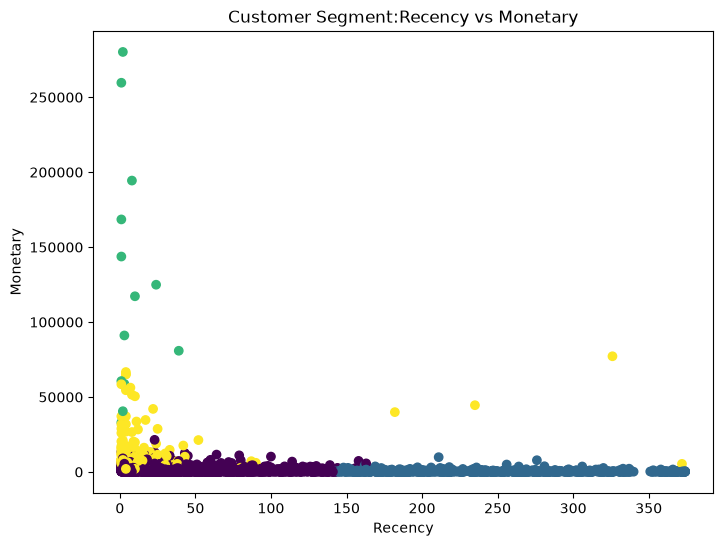

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(rfm['Recency'],rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segment:Recency vs Monetary")
plt.show()

## Customer Segment : Recency vs Monetary
- Customers with lower recency values have made purchases more recently.
- Customers who purchased recently tend to have higher monetary values than those who have not purchased for a long time.
- Customers with high recency and low monetary values may be at risk of becoming inactive.
- This visualization helps identify valuable customers and those who may need re-engagement campaigns.

In [43]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


In [44]:
cluster_summary=rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.631206
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


## Cluster Interpretation
### Cluster 0 - Regular Customers
- Moderate Recency
- Moderate Frequency
- Moderate Monetary
- These customers purchase occasionally and spend a moderate amount.

### Cluster 1 - Inactive Customers
- High Recency
- Low Frequency
- Low Monetary
- These customers haven't purchased for a long time, buy infrequently, and spend little.

### Cluster 2 - VIP Customers
- Low Recency
- High Frequency
- High Monetary
- These are our most valuable customers. They purchase very frequently,have bought recently, and spend the most money.

### Cluster 3 - Loyal Customers
- Low Recency
- High Frequency
- High Monetary
- These customers buy regularly and spend a good amount, though not as much as the VIP group.



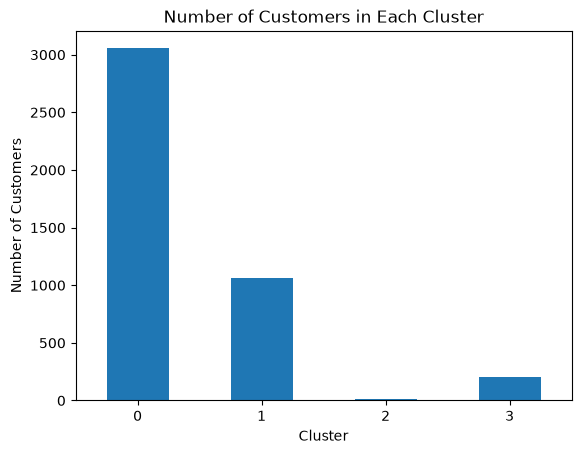

In [45]:
import matplotlib.pyplot as plt
rfm['Cluster'].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## Bar Chart Insights
- The bar chart shows the number of customers in each cluster.
- The clusters are not equally distributed, indicating different customer purchasing patterns.
- Cluster 0 contains the largest number of customers, indicating that it is the biggest customer segment in the dataset
- The bar chart shows that Cluster 2(VIP Customers)has the lowest customer count compared to the other cluster.
- The chart helps identify which customer segment is the largest and which is the smallest.

# Business Recommendations
- Cluster 0 (Regular Customers):Recommend related products and offer loyalty points.

- Cluster 1 (Inactive Customers):Send discount offers and re-engagement emails.

- Cluster 2 (VIP Customers): Provide premium support, exclusive offers, and VIP rewards.

- Cluster 3 (Loyal Customers):Offer loyalty rewards and personalized product recommendations.


## Conclusion
- This project successufully segmented customers into four groups using RFM analysis and K-Means clustering. the identified customers segments provide valuable insights into customer purchasins behaviour and can help businesses develop targeted marketing strategies, improve customer retention, and increase business revenue.